In [1]:
# Import libraries and load video-level data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

df_videos = pd.read_csv('../0_data/research_ready_videos.csv')
print(df_videos.shape)
df_videos.head()

(4143369, 9)


,video_id,channel_id,upload_date,title,tags,category,view_count,like_count,log_views
0,SBqSc91Hn9g,UCzWrhkg9eK5I8Bm3HfV-unA,2016-09-28 00:00:00,Lego City Police Lego Firetruck Cartoons about...,"lego city,lego police,lego city police,lego ci...",Film & Animation,1057.0,8.0,6.964136
1,UuugEl86ESY,UCzWrhkg9eK5I8Bm3HfV-unA,2016-09-28 00:00:00,Lego Marvel SuperHeroes Lego Hulk Smash Iron-M...,"Lego superheroes,lego hulk,hulk smash,lego mar...",Film & Animation,12894.0,23.0,9.464595
2,oB4c-yvnbjs,UCzWrhkg9eK5I8Bm3HfV-unA,2016-09-28 00:00:00,Lego City Police Lego Fireman Cartoons about L...,"lego city,lego police,lego city police,lego fi...",Film & Animation,1800602.0,1607.0,14.403632
3,ZaV-gTCMV8E,UCzWrhkg9eK5I8Bm3HfV-unA,2016-09-28 00:00:00,Lego Harry Potter Complete Lego New Movie for ...,"Lego harry potter,new harry potter,harry potte...",Film & Animation,57640.0,227.0,10.961989
4,cGvL7AvMfM0,UCzWrhkg9eK5I8Bm3HfV-unA,2016-09-28 00:00:00,Lego City Police 1 HOUR LONG VIDEO for kids Le...,"lego city,lego police,lego city police,lego fi...",Film & Animation,86368.0,105.0,11.366384


In [2]:
df_channels = pd.read_csv('../0_data/df_channels_en.tsv.gz', sep='\t', compression='gzip')
df_channels.head()

,category_cc,join_date,channel,name_cc,subscribers_cc,videos_cc,subscriber_rank_sb,weights
0,Gaming,2010-04-29,UC-lHJZR3Gqxm24_Vd_AJ5Yw,PewDiePie,101000000,3956,3.0,2.087
1,Education,2006-09-01,UCbCmjCuTUZos6Inko4u57UQ,Cocomelon - Nursery ...,60100000,458,7.0,2.087
2,Entertainment,2006-09-20,UCpEhnqL0y41EpW2TvWAHD7Q,SET India,56018869,32661,8.0,2.087
3,Howto & Style,2016-11-15,UC295-Dw_tDNtZXFeAPAW6Aw,5-Minute Crafts,60600000,3591,9.0,2.087
4,Sports,2007-05-11,UCJ5v_MCY6GNUBTO8-D3XoAg,WWE,48400000,43421,11.0,2.087


In [3]:
# Merge channel-level variables into each video row
# Match: df_videos.channel_id == df_channels.channel

df_channels_keyed = (
    df_channels
    .rename(columns={'channel': 'channel_id'})
    .drop_duplicates(subset=['channel_id'])
)

df_merged = pd.merge(
    df_videos,
    df_channels_keyed,
    on='channel_id',
    how='left',
    validate='many_to_one'
)

print(df_merged.shape)
df_merged.head()

(4143369, 16)


,video_id,channel_id,upload_date,title,tags,category,view_count,like_count,log_views,category_cc,join_date,name_cc,subscribers_cc,videos_cc,subscriber_rank_sb,weights
0,SBqSc91Hn9g,UCzWrhkg9eK5I8Bm3HfV-unA,2016-09-28 00:00:00,Lego City Police Lego Firetruck Cartoons about...,"lego city,lego police,lego city police,lego ci...",Film & Animation,1057.0,8.0,6.964136,Gaming,2013-08-26,Supertronic,314000,2398,54617.0,3.5155
1,UuugEl86ESY,UCzWrhkg9eK5I8Bm3HfV-unA,2016-09-28 00:00:00,Lego Marvel SuperHeroes Lego Hulk Smash Iron-M...,"Lego superheroes,lego hulk,hulk smash,lego mar...",Film & Animation,12894.0,23.0,9.464595,Gaming,2013-08-26,Supertronic,314000,2398,54617.0,3.5155
2,oB4c-yvnbjs,UCzWrhkg9eK5I8Bm3HfV-unA,2016-09-28 00:00:00,Lego City Police Lego Fireman Cartoons about L...,"lego city,lego police,lego city police,lego fi...",Film & Animation,1800602.0,1607.0,14.403632,Gaming,2013-08-26,Supertronic,314000,2398,54617.0,3.5155
3,ZaV-gTCMV8E,UCzWrhkg9eK5I8Bm3HfV-unA,2016-09-28 00:00:00,Lego Harry Potter Complete Lego New Movie for ...,"Lego harry potter,new harry potter,harry potte...",Film & Animation,57640.0,227.0,10.961989,Gaming,2013-08-26,Supertronic,314000,2398,54617.0,3.5155
4,cGvL7AvMfM0,UCzWrhkg9eK5I8Bm3HfV-unA,2016-09-28 00:00:00,Lego City Police 1 HOUR LONG VIDEO for kids Le...,"lego city,lego police,lego city police,lego fi...",Film & Animation,86368.0,105.0,11.366384,Gaming,2013-08-26,Supertronic,314000,2398,54617.0,3.5155


In [4]:
# Check missing values in df_merged
missing_counts = df_merged.isna().sum()
missing_pct = (missing_counts / len(df_merged) * 100).round(2)

missing_summary = (
    pd.DataFrame({
        'missing_count': missing_counts,
        'missing_pct': missing_pct
    })
    .sort_values('missing_count', ascending=False)
)

print(f"Total rows: {len(df_merged):,}")
print(f"Columns with at least 1 missing value: {(missing_summary['missing_count'] > 0).sum()}")

missing_summary[missing_summary['missing_count'] > 0].head(20)

Total rows: 4,143,369
Columns with at least 1 missing value: 6


,missing_count,missing_pct
tags,444549,10.73
like_count,88195,2.13
category_cc,3510,0.08
join_date,296,0.01
category,41,0.00
title,2,0.00


In [13]:
# Handle missing values (hybrid strategy)
# 1) Drop tiny missingness in core text/category fields
# 2) Impute larger/feature missingness and keep missingness indicators

df_clean = df_merged.copy()
rows_before = len(df_clean)

# Missingness indicators (keep information that values were missing)
df_clean['like_count_missing'] = df_clean['like_count'].isna().astype(int)
df_clean['tags_missing'] = df_clean['tags'].isna().astype(int)
df_clean['category_cc_missing'] = df_clean['category_cc'].isna().astype(int)
df_clean['join_date_missing'] = df_clean['join_date'].isna().astype(int)

# Drop rows with missing core fields (very small share)
df_clean = df_clean.dropna(subset=['title', 'category'])

# Impute feature fields
df_clean['tags'] = df_clean['tags'].fillna('')
df_clean['like_count'] = df_clean['like_count'].fillna(0)
df_clean['category_cc'] = df_clean['category_cc'].fillna('Unknown')
df_clean['join_date'] = df_clean['join_date'].fillna('Unknown')

# Check post-cleaning missingness
missing_after = df_clean.isna().sum()
remaining_missing = missing_after[missing_after > 0].sort_values(ascending=False)

print(f"Rows before cleaning: {rows_before:,}")
print(f"Rows after cleaning:  {len(df_clean):,}")
print(f"Rows dropped:         {rows_before - len(df_clean):,}")

if len(remaining_missing) == 0:
    print("No missing values remain in df_clean.")
else:
    print("Columns still containing missing values:")
    display((remaining_missing / len(df_clean) * 100).round(2).rename('missing_pct'))

Rows before cleaning: 4,143,369
Rows after cleaning:  4,143,326
Rows dropped:         43
No missing values remain in df_clean.


In [14]:
# Build engagement variables used for target construction
# Note: rel_log_engagement based on full-sample channel medians is NOT used as target
# because it can leak future information.

df_stage2 = df_clean.copy()

# Safe division in case any zero-view rows appear
df_stage2['engagement_rate'] = np.where(
    df_stage2['view_count'] > 0,
    df_stage2['like_count'] / df_stage2['view_count'],
    np.nan
)

df_stage2['engagement_pct'] = df_stage2['engagement_rate'] * 100
df_stage2['log_engagement'] = np.log1p(df_stage2['engagement_pct'])

df_stage2['log_views'] = np.log1p(df_stage2['view_count'])
df_stage2['log_subscribers_cc'] = np.log1p(df_stage2['subscribers_cc'])

print('Created core performance variables:')
print('- engagement_rate')
print('- engagement_pct')
print('- log_engagement')
print('- log_views')
print('- log_subscribers_cc')

display(df_stage2[['engagement_rate', 'engagement_pct', 'log_engagement', 'log_views']].describe().T)

Created core performance variables:
- engagement_rate
- engagement_pct
- log_engagement
- log_views
- log_subscribers_cc


,count,mean,std,min,25%,50%,75%,max
engagement_rate,4143326.0,0.024857,0.030415,0.000000,0.006612,0.016594,0.033606,12.072235
engagement_pct,4143326.0,2.485665,3.041498,0.000000,0.661187,1.659407,3.360628,1207.223476
log_engagement,4143326.0,1.021063,0.649070,0.000000,0.507532,0.978103,1.472616,7.096906
log_views,4143326.0,8.510760,2.477961,0.693147,6.823286,8.400659,10.120492,21.768327


In [ ]:
# Build panel structure and strict category-switch feature

MIN_STABLE_PRE = 3

df_stage2 = df_stage2.copy()
df_stage2['upload_date'] = pd.to_datetime(df_stage2['upload_date'], errors='coerce')
df_stage2 = df_stage2.dropna(subset=['upload_date']).sort_values(['channel_id', 'upload_date']).reset_index(drop=True)

df_stage2['year_month'] = df_stage2['upload_date'].dt.to_period('M').astype(str)
df_stage2['prev_category'] = df_stage2.groupby('channel_id')['category'].shift(1)

# Build within-channel category runs
is_new_run = df_stage2['category'] != df_stage2.groupby('channel_id')['category'].shift(1)
df_stage2['category_run_id'] = is_new_run.groupby(df_stage2['channel_id']).cumsum()
df_stage2['run_pos'] = df_stage2.groupby(['channel_id', 'category_run_id']).cumcount() + 1

# Strict switching: category changes only after >=3 stable uploads in prior category
prev_run_length = df_stage2.groupby('channel_id')['run_pos'].shift(1)
is_category_change = df_stage2['prev_category'].notna() & (df_stage2['category'] != df_stage2['prev_category'])
df_stage2['category_switch'] = (is_category_change & (prev_run_length >= MIN_STABLE_PRE)).astype(int)

print(f"Panel rows after date parsing: {len(df_stage2):,}")
print(f"Strict switch share (>= {MIN_STABLE_PRE} prior stable videos): {df_stage2['category_switch'].mean():.4f}")

Panel rows after date parsing: 4,143,326
Strict switch share (>= 3 prior stable videos): 0.0165


In [21]:
# Construct rolling historical features (past-only to avoid leakage)

df_stage2 = df_stage2.sort_values(['channel_id', 'upload_date']).copy()

# Lagged outcomes
df_stage2['lag_log_engagement'] = df_stage2.groupby('channel_id')['log_engagement'].shift(1)
df_stage2['lag_log_views'] = df_stage2.groupby('channel_id')['log_views'].shift(1)

# Rolling baselines from prior uploads only
grouped = df_stage2.groupby('channel_id')
df_stage2['roll_median_log_engagement_10'] = grouped['log_engagement'].transform(
    lambda s: s.shift(1).rolling(window=10, min_periods=5).median()
)
df_stage2['roll_mean_log_views_10'] = grouped['log_views'].transform(
    lambda s: s.shift(1).rolling(window=10, min_periods=5).mean()
)
df_stage2['roll_std_log_engagement_10'] = grouped['log_engagement'].transform(
    lambda s: s.shift(1).rolling(window=10, min_periods=5).std()
)

# Cadence variables
df_stage2['prev_upload_date'] = grouped['upload_date'].shift(1)
df_stage2['upload_gap_days'] = (df_stage2['upload_date'] - df_stage2['prev_upload_date']).dt.days

# Upload frequency in the past 30 days (prior uploads only)
def prior_uploads_30d(dates):
    vals = dates.to_numpy(dtype='datetime64[ns]')
    out = np.zeros(len(vals), dtype=float)
    left = 0
    for i in range(len(vals)):
        while left < i and vals[left] < vals[i] - np.timedelta64(30, 'D'):
            left += 1
        out[i] = i - left
    return pd.Series(out, index=dates.index)

df_stage2['recent_upload_freq_30d'] = grouped['upload_date'].apply(prior_uploads_30d).reset_index(level=0, drop=True)

# Transform skewed cadence variables for modeling
df_stage2['upload_gap_days_log1p'] = np.log1p(df_stage2['upload_gap_days'].clip(lower=0))
df_stage2['recent_upload_freq_30d_log1p'] = np.log1p(df_stage2['recent_upload_freq_30d'].clip(lower=0))
df_stage2['same_day_upload'] = (df_stage2['upload_gap_days'] == 0).astype(int)

print('Constructed leakage-safe historical features:')
print('- lag_log_engagement, lag_log_views')
print('- roll_median_log_engagement_10')
print('- roll_mean_log_views_10')
print('- roll_std_log_engagement_10')
print('- upload_gap_days, recent_upload_freq_30d')
print('- upload_gap_days_log1p, recent_upload_freq_30d_log1p, same_day_upload')

Constructed leakage-safe historical features:
- lag_log_engagement, lag_log_views
- roll_median_log_engagement_10
- roll_mean_log_views_10
- roll_std_log_engagement_10
- upload_gap_days, recent_upload_freq_30d
- upload_gap_days_log1p, recent_upload_freq_30d_log1p, same_day_upload


In [22]:
# Define binary target: underperform_flag
# 1 if current log_engagement is below channel's rolling historical median.

df_stage2['underperform_flag'] = (
    df_stage2['log_engagement'] < df_stage2['roll_median_log_engagement_10']
).astype('float')

required_for_target = [
    'underperform_flag',
    'roll_median_log_engagement_10',
    'lag_log_engagement',
    'lag_log_views',
    'upload_gap_days',
    'recent_upload_freq_30d'
]

df_model = df_stage2.dropna(subset=required_for_target).copy()
df_model['underperform_flag'] = df_model['underperform_flag'].astype(int)

print(f"Rows available for modeling: {len(df_model):,}")
print(f"Channels in model sample: {df_model['channel_id'].nunique():,}")
print(f"Switch share: {df_model['category_switch'].mean():.4f}")
print(f"Underperform class share: {df_model['underperform_flag'].mean():.4f}")

Rows available for modeling: 4,094,101
Channels in model sample: 9,845
Switch share: 0.0165
Underperform class share: 0.4695


In [23]:
# Create time-based train/validation/test split (leakage-safe)

feature_cols_num = [
    'category_switch',
    'run_pos',
    'upload_gap_days_log1p',
    'recent_upload_freq_30d_log1p',
    'same_day_upload',
    'lag_log_engagement',
    'lag_log_views',
    'roll_median_log_engagement_10',
    'roll_mean_log_views_10',
    'roll_std_log_engagement_10',
    'log_subscribers_cc',
    'videos_cc',
    'like_count_missing',
    'tags_missing',
    'category_cc_missing',
    'join_date_missing'
]
feature_cols_cat = ['category', 'prev_category', 'category_cc']

required_for_features = feature_cols_num + feature_cols_cat + ['underperform_flag', 'upload_date', 'year_month']
df_ml = df_model.dropna(subset=required_for_features).copy()

# Time-aware split (no random row split)
df_ml = df_ml.sort_values('upload_date').copy()
cut_train = df_ml['upload_date'].quantile(0.70)
cut_valid = df_ml['upload_date'].quantile(0.85)

df_ml['split'] = np.select(
    [df_ml['upload_date'] <= cut_train, df_ml['upload_date'] <= cut_valid],
    ['train', 'valid'],
    default='test'
)

print('Split sizes:')
print(df_ml['split'].value_counts())

print('\nClass balance by split (underperform_flag mean):')
print(df_ml.groupby('split')['underperform_flag'].mean().round(4))

print('\nFeature groups for modeling notebook:')
print(f"Numeric features: {len(feature_cols_num)}")
print(f"Categorical features: {len(feature_cols_cat)}")

Split sizes:
split
train    2866111
valid     614519
test      613471
Name: count, dtype: int64

Class balance by split (underperform_flag mean):
split
test     0.4631
train    0.4701
valid    0.4727
Name: underperform_flag, dtype: float64

Feature groups for modeling notebook:
Numeric features: 16
Categorical features: 3


Target and switching summaries
----------------------------------------
Underperform class balance (overall):
underperform_flag
0    0.5305
1    0.4695
Name: share, dtype: float64

Category switch frequency (overall):
category_switch
0    0.9835
1    0.0165
Name: share, dtype: float64

Key feature distributions:


,count,mean,std,min,25%,50%,75%,max
upload_gap_days_log1p,4094101.0,0.878912,0.955241,0.00000,0.000000,0.693147,1.386294,8.137980
log_subscribers_cc,4094101.0,11.383938,1.604719,9.21044,10.070907,11.042938,12.409018,18.430631
lag_log_engagement,4094101.0,1.021207,0.648888,0.00000,0.508138,0.978693,1.472648,7.096906
recent_upload_freq_30d_log1p,4094101.0,3.038038,1.272662,0.00000,2.197225,3.091042,3.871201,7.672758
same_day_upload,4094101.0,0.362174,0.480629,0.00000,0.000000,0.000000,1.000000,1.000000


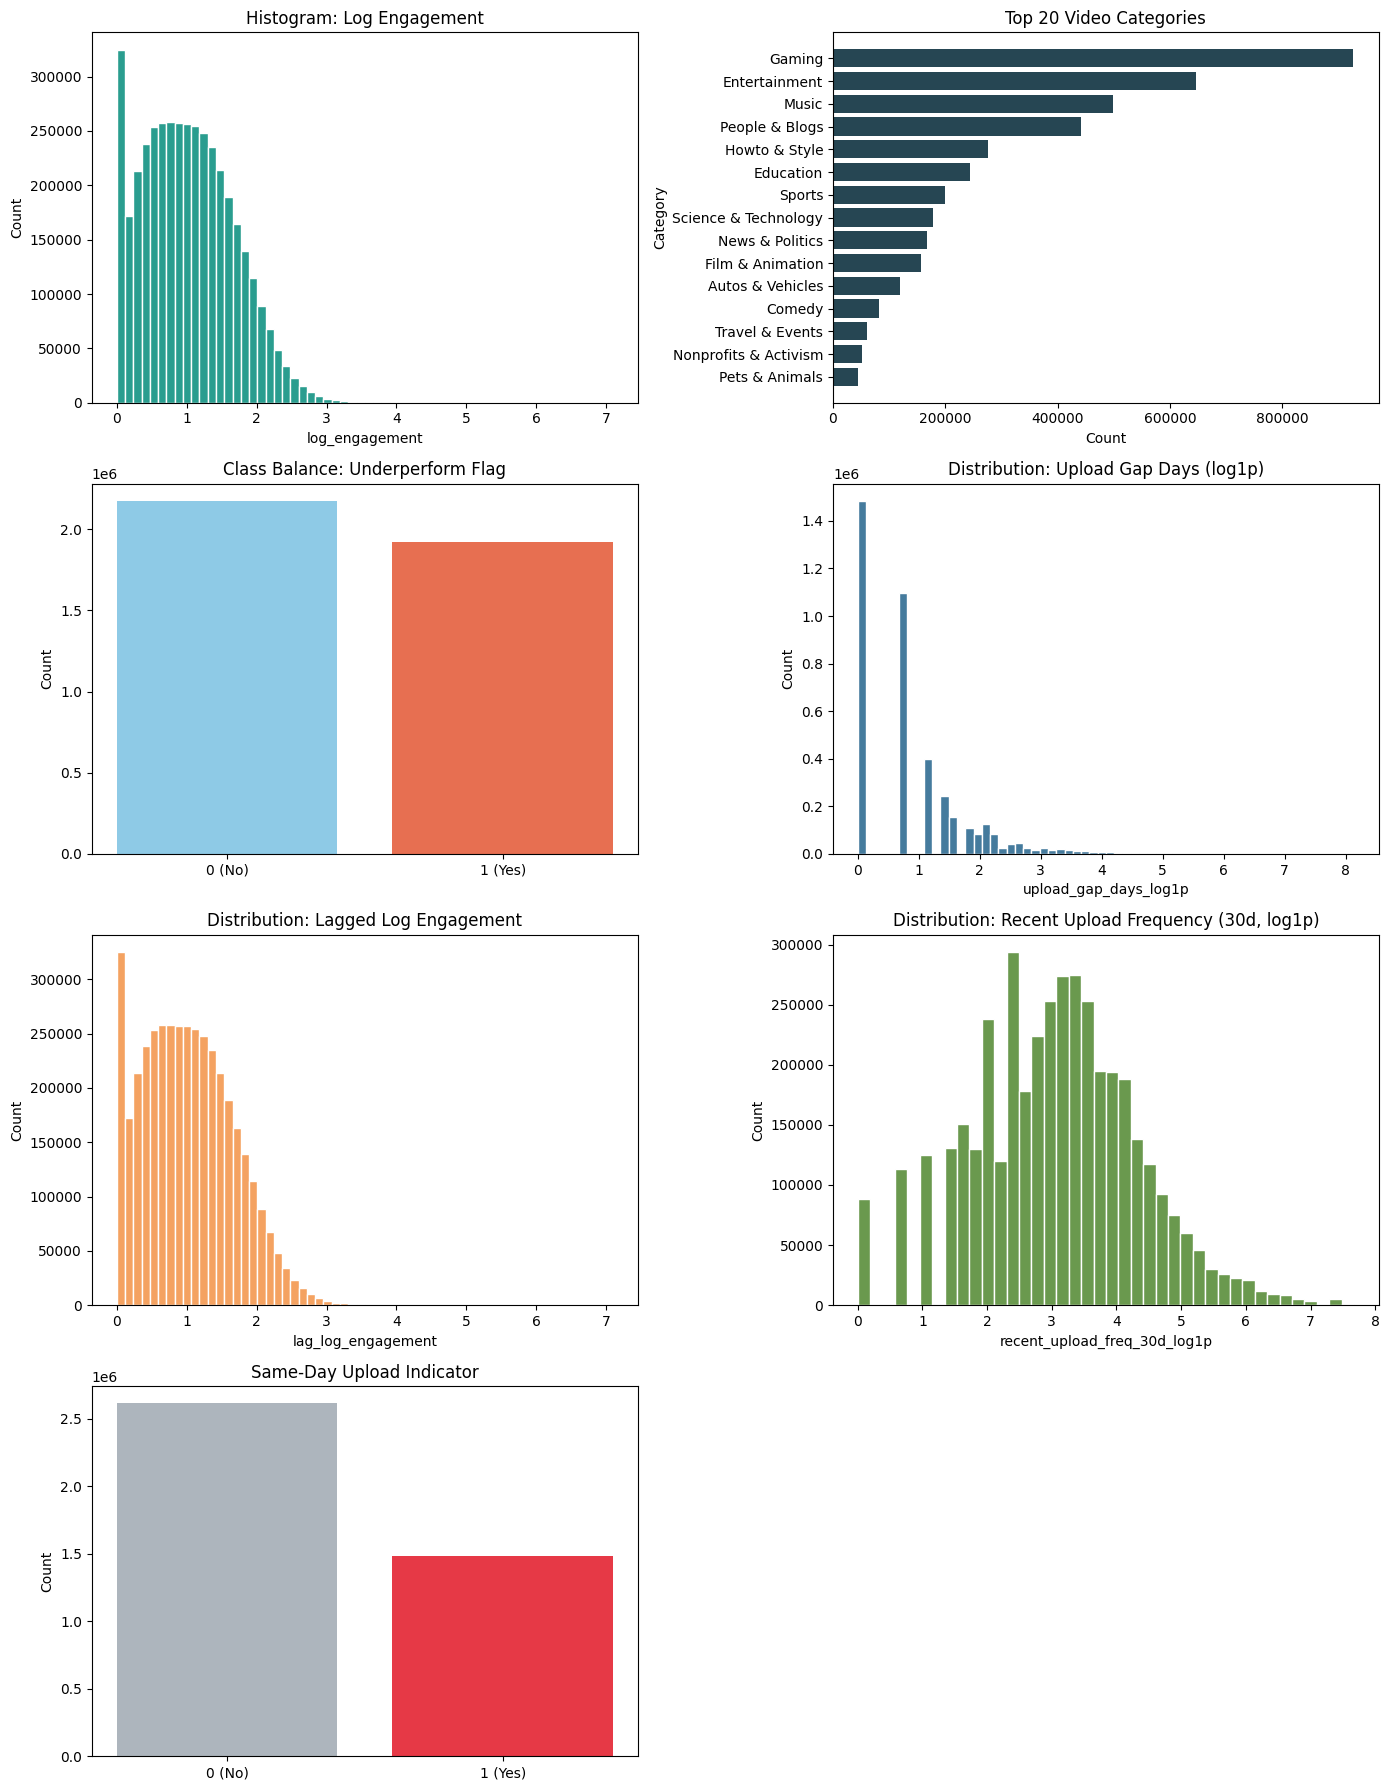

In [27]:
# Additional descriptives
# Focus: target distribution, switching frequency, key predictor distributions, and requested charts.

import matplotlib.pyplot as plt

print('Target and switching summaries')
print('-' * 40)
print('Underperform class balance (overall):')
print(df_ml['underperform_flag'].value_counts(normalize=True).rename('share').round(4))
print('\nCategory switch frequency (overall):')
print(df_ml['category_switch'].value_counts(normalize=True).rename('share').round(4))

# Core descriptive table for key predictive features
key_features = [
    'upload_gap_days_log1p',
    'log_subscribers_cc',
    'lag_log_engagement',
    'recent_upload_freq_30d_log1p',
    'same_day_upload'
]
print('\nKey feature distributions:')
display(df_ml[key_features].describe().T)

# Plotting section
fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()

# 1) Histogram of log-transformed engagement
axes[0].hist(df_ml['log_engagement'].dropna(), bins=60, color='#2a9d8f', edgecolor='white')
axes[0].set_title('Histogram: Log Engagement')
axes[0].set_xlabel('log_engagement')
axes[0].set_ylabel('Count')

# 2) Bar chart of category counts (top 20)
category_counts = df_ml['category'].value_counts().head(20)
axes[1].barh(category_counts.index[::-1], category_counts.values[::-1], color='#264653')
axes[1].set_title('Top 20 Video Categories')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('Category')

# 3) Class-balance plot for underperform label
under_counts = df_ml['underperform_flag'].value_counts().sort_index()
axes[2].bar(['0 (No)', '1 (Yes)'], under_counts.values, color=['#8ecae6', '#e76f51'])
axes[2].set_title('Class Balance: Underperform Flag')
axes[2].set_ylabel('Count')

# 4) Upload gap (log1p) distribution
axes[3].hist(df_ml['upload_gap_days_log1p'].dropna(), bins=60, color='#457b9d', edgecolor='white')
axes[3].set_title('Distribution: Upload Gap Days (log1p)')
axes[3].set_xlabel('upload_gap_days_log1p')
axes[3].set_ylabel('Count')

# 5) Lagged engagement distribution
axes[4].hist(df_ml['lag_log_engagement'].dropna(), bins=60, color='#f4a261', edgecolor='white')
axes[4].set_title('Distribution: Lagged Log Engagement')
axes[4].set_xlabel('lag_log_engagement')
axes[4].set_ylabel('Count')

# 6) Recent posting frequency (log1p) distribution
axes[5].hist(df_ml['recent_upload_freq_30d_log1p'].dropna(), bins=40, color='#6a994e', edgecolor='white')
axes[5].set_title('Distribution: Recent Upload Frequency (30d, log1p)')
axes[5].set_xlabel('recent_upload_freq_30d_log1p')
axes[5].set_ylabel('Count')

# 7) Same-day upload indicator distribution
same_day_counts = df_ml['same_day_upload'].value_counts().sort_index()
axes[6].bar(['0 (No)', '1 (Yes)'], same_day_counts.reindex([0, 1], fill_value=0).values, color=['#adb5bd', '#e63946'])
axes[6].set_title('Same-Day Upload Indicator')
axes[6].set_ylabel('Count')

# 8) Keep final panel blank for cleaner layout
axes[7].axis('off')

plt.tight_layout()
plt.show()

In [25]:
# Save ML-ready datasets and quick class diagnostics

cols_to_keep = [
    'video_id', 'channel_id', 'upload_date', 'year_month',
    'category', 'prev_category', 'category_switch', 'run_pos',
    'view_count', 'like_count',
    'engagement_rate', 'engagement_pct', 'log_engagement', 'log_views',
    'roll_median_log_engagement_10', 'roll_mean_log_views_10', 'roll_std_log_engagement_10',
    'lag_log_engagement', 'lag_log_views',
    'upload_gap_days', 'upload_gap_days_log1p',
    'recent_upload_freq_30d', 'recent_upload_freq_30d_log1p', 'same_day_upload',
    'subscribers_cc', 'log_subscribers_cc', 'videos_cc', 'category_cc',
    'like_count_missing', 'tags_missing', 'category_cc_missing', 'join_date_missing',
    'underperform_flag', 'split'
]

cols_available = [c for c in cols_to_keep if c in df_ml.columns]
df_stage2_ml_ready = df_ml[cols_available].copy()

output_panel = '../0_data/stage2_ml_ready.csv'
df_stage2_ml_ready.to_csv(output_panel, index=False)

print(f"Saved ML-ready panel: {output_panel}")
print(f"Rows: {len(df_stage2_ml_ready):,}")
print(f"Columns: {len(df_stage2_ml_ready.columns):,}")

print('\nClass balance by split (underperform_flag mean):')
print(df_stage2_ml_ready.groupby('split')['underperform_flag'].mean().round(4))

Saved ML-ready panel: ../0_data/stage2_ml_ready.csv
Rows: 4,094,101
Columns: 34

Class balance by split (underperform_flag mean):
split
test     0.4631
train    0.4701
valid    0.4727
Name: underperform_flag, dtype: float64


In [26]:
# Final preview of the modeling table

df_stage2_ml_ready.head()

,video_id,channel_id,upload_date,year_month,category,prev_category,category_switch,run_pos,view_count,like_count,...,subscribers_cc,log_subscribers_cc,videos_cc,category_cc,like_count_missing,tags_missing,category_cc_missing,join_date_missing,underperform_flag,split
1010252,rNVzui7K7Ec,UCE_q1aG7en0lunaYUECTMQg,2006-04-14,2006-04,Film & Animation,Film & Animation,0,6,7917.0,24.0,...,12100,9.401043,307,People & Blogs,0,0,0,0,0,train
1010253,Fx9nzbtFLzU,UCE_q1aG7en0lunaYUECTMQg,2006-04-17,2006-04,Film & Animation,Film & Animation,0,7,1529.0,6.0,...,12100,9.401043,307,People & Blogs,0,0,0,0,0,train
1010254,acnnzoZ24NA,UCE_q1aG7en0lunaYUECTMQg,2006-04-17,2006-04,Film & Animation,Film & Animation,0,8,4623.0,20.0,...,12100,9.401043,307,People & Blogs,0,0,0,0,0,train
635190,fQCtqu_YVy0,UC9Gfy8SldXUR-sbZCNISs-Q,2006-04-25,2006-04,News & Politics,News & Politics,0,6,40418.0,262.0,...,117000,11.669938,1725,People & Blogs,0,0,0,0,1,train
1010255,54f91WlHBs4,UCE_q1aG7en0lunaYUECTMQg,2006-04-27,2006-04,Film & Animation,Film & Animation,0,9,2262.0,8.0,...,12100,9.401043,307,People & Blogs,0,0,0,0,0,train
